# icet cross-check of homegrown Gibbs oracle (D=2)

**Purpose.** Validate `discrete_flow_sampler.mcmc.gibbs.gibbs_sample` against an *independent* implementation of the same physical system. We re-encode the 2D periodic Ising Hamiltonian as a binary alloy cluster expansion in `icet` and run Monte Carlo with `mchammer.SGCEnsemble`. If three distributions — exact enumeration, our Gibbs, and mchammer SGC — all agree to TVD < 0.02 on D=2 (|S|=16 states), the Gibbs oracle is trustworthy as the reference for downstream DNFS comparisons.

**Why D=2 (not the plan's nominal D=4).** Empirical-TVD floor for N samples over |S| states is ~√(|S|/N). For TVD < 0.02 on |S|=65,536 (D=4) we'd need N ≈ 1.6·10⁸ samples — infeasible on a laptop. D=2 has |S|=16, so N ≈ 40k is sufficient and we use N = 200k for ~5× headroom. The cross-check question (do these three distributions agree?) is just as well-posed at D=2; any bug in Gibbs or in the alloy mapping would still surface. This matches the Task 4 D=2 small-lattice gate.

**Mapping Ising ↔ binary alloy.** Replace each spin $x_i \in \{-1, +1\}$ with a species: A ↔ +1, B ↔ -1. Set `IsingTarget(bias=0)` so there's no external field — corresponds to $\Delta\mu = 0$ in the SGC ensemble (composition fluctuates freely). We need the alloy cluster expansion's energy to equal $-\log p(x)$ up to an additive constant in $x$ (constants cancel in the Boltzmann weight). Two indexing conventions are at play:

1. Our `IsingTarget.J` *double-counts* edges: `J[i,j] = J[j,i] = sigma`, so $x^\top J x$ picks up $2\sigma$ per unordered NN pair.
2. icet's pair-cluster basis carries internal multiplicity / normalisation conventions that depend on the lattice and the icet version.

Rather than chase the constants analytically, we **fit the cluster expansion parameters directly by linear regression** against $-\log p(x)$ on a handful of random configurations. Since the Ising Hamiltonian IS exactly representable by an NN-pair CE, the regression has zero residual *iff* the setup is correct — making this the loudest, earliest mis-specification check we can build before sampling.

**Small-lattice caveat.** In the 2×2 periodic grid, the wrap-around makes each NN pair carry an extra geometric multiplicity (left and right of a site are the same neighbour). The CE absorbs this naturally because we calibrate on actual `target.log_prob` values, but it's worth knowing.

Reference for icet/mchammer syntax: `notebooks/icet_agpb_tutorial.ipynb`.

## 1. Setup

In [1]:
import numpy as np
import torch

from discrete_flow_sampler.targets.ising import IsingTarget
from discrete_flow_sampler.mcmc.gibbs import gibbs_sample
from discrete_flow_sampler.diagnostics.metrics import (
    enumerate_states,
    exact_log_probs,
    tvd,
)

from ase import Atoms
from icet import ClusterSpace, ClusterExpansion
from mchammer.calculators import ClusterExpansionCalculator
from mchammer.ensembles import SemiGrandCanonicalEnsemble

D = 2
sigma = 0.1
torch.manual_seed(0)
np.random.seed(0)

target = IsingTarget(D=D, sigma=sigma, bias=0.0)
print(f'D={D}, d={target.d} sites, |S|=2**d={2**target.d} states, sigma={sigma}')

D=2, d=4 sites, |S|=2**d=16 states, sigma=0.1


## 2. Construct the binary alloy cluster expansion that matches Ising

**Primitive lattice.** A single-atom unit cell on a 2D square lattice (lattice constant 1.0), with the third axis vacuum-padded and non-periodic so it stays effectively 2D under icet's 3D crystallographic machinery. The supercell is the D×D×1 repeat — exactly mirrors `IsingTarget`'s D×D toroidal grid.

**Cluster space.** Pair cutoff slightly above 1.0 (the NN distance) but below √2 (the 2-NN diagonal distance), so only NN pairs enter. With one site per primitive cell and a binary alphabet, this gives 3 cluster-vector components: zerolet (constant), singlet (mean spin), pair (NN spin product).

**Species ↔ spin convention.** First symbol in `chemical_symbols` (`'Au'`) maps to spin +1; second (`'Pd'`) to spin -1. icet's spin-product basis follows this ordering.

In [2]:
a_lat = 1.0
# pbc=[True, True, True] is required by icet, but the long c-axis (20·a_lat)
# keeps any z-direction "neighbour" well outside the NN cutoff (1.1·a_lat),
# so the lattice behaves as 2D for clustering purposes.
prim = Atoms(
    symbols='Au',
    positions=[[0.0, 0.0, 0.0]],
    cell=[[a_lat, 0.0, 0.0], [0.0, a_lat, 0.0], [0.0, 0.0, 20.0 * a_lat]],
    pbc=[True, True, True],
)
supercell = prim.repeat((D, D, 1))
assert len(supercell) == target.d, 'supercell site count must match target.d'

# Build spin -> atom permutation by matching positions.
# IsingTarget convention: spin i lives at (row = i // D, col = i % D);
# geometric (x = col, y = row). ASE's repeat ordering may differ
# (it iterates y before x), so we look up each spin's atom by position.
target_xy = np.array([(i % D * a_lat, i // D * a_lat) for i in range(target.d)])
atom_xy = supercell.positions[:, :2]
spin_to_atom = np.zeros(target.d, dtype=int)
for i, (px, py) in enumerate(target_xy):
    match = np.where(np.isclose(atom_xy[:, 0], px) & np.isclose(atom_xy[:, 1], py))[0]
    assert len(match) == 1, f'expected 1 atom at ({px},{py}), got {len(match)}'
    spin_to_atom[i] = match[0]
print('spin_to_atom:', spin_to_atom,
      'identity?', np.array_equal(spin_to_atom, np.arange(target.d)))

# Cluster space: NN pair only (cutoff between 1.0 and sqrt(2) ~ 1.414)
nn_cutoff = 1.1
cs = ClusterSpace(
    structure=prim,
    cutoffs=[nn_cutoff],
    chemical_symbols=['Au', 'Pd'],
)
print(cs)

spin_to_atom: [0 2 1 3] identity? False
====================================== Cluster Space ======================================
 space group                            : P4/mmm (123)
 chemical species                       : ['Au', 'Pd'] (sublattice A)
 cutoffs                                : 1.1000
 total number of parameters             : 3
 number of parameters by order          : 0= 1  1= 1  2= 1
 fractional_position_tolerance          : 2e-06
 position_tolerance                     : 1e-05
 symprec                                : 1e-05
-------------------------------------------------------------------------------------------
index | order |  radius  | multiplicity | orbit_index | multicomponent_vector | sublattices
-------------------------------------------------------------------------------------------
   0  |   0   |   0.0000 |        1     |      -1     |           .           |      .     
   1  |   1   |   0.0000 |        1     |       0     |          [0]          |

## 3. Calibrate cluster-expansion parameters by linear regression

We solve $\Phi \beta = y$ where $\Phi_{i,k}$ is the $k$-th cluster-vector component of configuration $i$ and $y_i = -\log p(x_i)$. Since the Ising Hamiltonian lives exactly in the span of [zerolet, singlet, pair], `lstsq` returns parameters with zero residual when the setup is correct. A non-zero residual means the alloy mapping is broken (wrong species ordering, wrong cutoff, etc.) and you should fix that *before* running MC.

In [3]:
def spins_to_symbols(spins):
    """Spin array in {-1, +1} (IsingTarget order) -> symbols (atom order)."""
    spins = np.asarray(spins).ravel()
    syms = ['Au'] * target.d
    for i, s in enumerate(spins):
        syms[spin_to_atom[i]] = 'Au' if s > 0 else 'Pd'
    return syms


def symbols_to_spins(syms):
    """Symbols (atom order) -> spin array (IsingTarget order)."""
    return np.array(
        [1 if syms[spin_to_atom[i]] == 'Au' else -1 for i in range(target.d)],
        dtype=np.int8,
    )


def make_alloy(spins):
    """Apply a spin configuration to a fresh copy of the supercell."""
    a = supercell.copy()
    a.set_chemical_symbols(spins_to_symbols(spins))
    return a


n_calib = 16
calib_seed = torch.Generator().manual_seed(42)
spins_calib = torch.randint(0, 2, (n_calib, target.d), generator=calib_seed).float() * 2 - 1
neg_log_prob = (-target.log_prob(spins_calib)).numpy()

cluster_vectors = np.array([
    cs.get_cluster_vector(make_alloy(s.numpy())) for s in spins_calib
])
print('cluster_vectors shape:', cluster_vectors.shape)

params, residuals, rank, _ = np.linalg.lstsq(cluster_vectors, neg_log_prob, rcond=None)
print('raw fitted parameters [zerolet, singlet, pair]:', params)
ssr = float(residuals[0]) if len(residuals) else None
print(f'lstsq sum-squared-residuals: {ssr if ssr is not None else "(rank-deficient)"}')
if ssr is not None:
    assert ssr < 1e-16, 'CE does not match Ising — fix mapping before continuing'

# Rescale ECI by N_pc so the supercell-summed energy (what mchammer's
# ClusterExpansionCalculator returns via calculate_total) matches -log_prob.
# `cs.get_cluster_vector(structure)` is intensive (per-orbit average), and
# the calculator multiplies by N_pc internally; the lstsq fit treats
# cluster_vectors as if extensive, so we compensate by dividing here.
n_prim_in_supercell = len(supercell) // len(prim)
params = params / n_prim_in_supercell
print(f'rescaled params (factor 1/{n_prim_in_supercell}):', params)
print('singlet (should be ~0 since bias=0):', float(params[1]))

cluster_vectors shape: (16, 3)
raw fitted parameters [zerolet, singlet, pair]: [ 2.83203324e-17 -2.22044605e-16 -1.60000002e+00]
lstsq sum-squared-residuals: 7.042398370876108e-32
rescaled params (factor 1/4): [ 7.08008309e-18 -5.55111512e-17 -4.00000006e-01]
singlet (should be ~0 since bias=0): -5.551115123125783e-17


## 4. Build the cluster expansion and verify on hold-out configurations

Sanity check: 50 fresh random configs, expect `|alloy_E - ising_E|` machine-zero up to additive constant (which the calibration absorbed). If this assertion fails, something changed between calibration and verification (rare, but possible if you re-ran cells out of order).

In [4]:
ce = ClusterExpansion(cluster_space=cs, parameters=params)

# Verify the *calculator* (what mchammer actually uses) matches Ising energy.
# This is the relevant invariant: SGC's accept/reject sees calculate_total,
# not ce.predict, so this is the test that gates correct sampling.
ref_atoms = make_alloy(np.ones(target.d))
calc_ref = ClusterExpansionCalculator(ref_atoms, ce)

n_verify = 50
verify_seed = torch.Generator().manual_seed(43)
spins_verify = torch.randint(0, 2, (n_verify, target.d), generator=verify_seed).float() * 2 - 1
errors = []
for s in spins_verify:
    occ = make_alloy(s.numpy()).get_atomic_numbers()
    e_mc = float(calc_ref.calculate_total(occupations=occ))
    e_ising = float(-target.log_prob(s.unsqueeze(0)).item())
    errors.append(abs(e_mc - e_ising))
max_err = max(errors)
print(f'max |calc.calculate_total - Ising E| over {n_verify}: {max_err:.2e}')
assert max_err < 1e-6, 'mchammer calculator energy disagrees with Ising — re-check ECI scaling'

icet: WARNING  The ClusterExpansionCalculator self-interacts, which may lead to erroneous results. To avoid self-interaction, use a larger supercell or a cluster space with shorter cutoffs.


max |calc.calculate_total - Ising E| over 50: 4.44e-16


## 5. Run mchammer SGC at Δμ = 0

Single chain, burn-in then thinned collection. With temperature=1.0 and `chemical_potentials={'Au': 0, 'Pd': 0}` the SGC weight is $\exp(-E)$, which equals $\exp(\log p(x)) = p(x)$ by construction.

**Thinning.** mchammer's auto-correlation analysis reports lag in *trial steps*, not entries — see `~/.claude/.../memory/project_mchammer_correlation_length_units.md`. We thin every 10 trial steps; for D=2 with σ=0.1 the system is well in the high-temperature phase and mixing is fast. If you find empirical TVD plateauing above 0.02, increase thinning (or burn-in).

In [5]:
init_seed = torch.Generator().manual_seed(7)
init_spins = (torch.randint(0, 2, (target.d,), generator=init_seed).float() * 2 - 1).numpy()
mc_atoms = make_alloy(init_spins)
calc = ClusterExpansionCalculator(mc_atoms, ce)

ensemble = SemiGrandCanonicalEnsemble(
    structure=mc_atoms,
    calculator=calc,
    temperature=1.0,
    chemical_potentials={'Au': 0.0, 'Pd': 0.0},
    boltzmann_constant=1.0,  # override default eV/K so kT == T == 1
    dc_filename=None,
)

n_burn = 5_000          # trial steps
n_samples = 200_000
k_thin = 10             # trial steps between recorded samples

ensemble.run(n_burn)

samples_sgc = np.zeros((n_samples, target.d), dtype=np.int8)
for i in range(n_samples):
    ensemble.run(k_thin)
    syms = ensemble.structure.get_chemical_symbols()
    samples_sgc[i] = symbols_to_spins(syms)
samples_sgc = torch.from_numpy(samples_sgc).float()
print('SGC samples:', samples_sgc.shape, 'value set:', torch.unique(samples_sgc).tolist())

icet: WARNING  The ClusterExpansionCalculator self-interacts, which may lead to erroneous results. To avoid self-interaction, use a larger supercell or a cluster space with shorter cutoffs.


SGC samples: torch.Size([200000, 4]) value set: [-1.0, 1.0]


## 6. Run our Gibbs sampler (long single chain)

Burn-in 2k sweeps, then collect one sample per sweep. One sweep updates every site once, so for D=2 (4 sites) one sweep ≈ 4 single-spin updates — comparable in unit-of-work to mchammer's per-trial-step convention but not identical.

In [6]:
gibbs_init_seed = torch.Generator().manual_seed(11)
x_state = (torch.randint(0, 2, (1, target.d), generator=gibbs_init_seed).float() * 2 - 1)

gibbs_seed = torch.Generator().manual_seed(13)
x_state = gibbs_sample(target, n_chains=1, n_sweeps=2_000, x_init=x_state, generator=gibbs_seed)

n_samples_gibbs = 200_000
samples_gibbs = torch.zeros(n_samples_gibbs, target.d)
for i in range(n_samples_gibbs):
    x_state = gibbs_sample(target, n_chains=1, n_sweeps=1, x_init=x_state, generator=gibbs_seed)
    samples_gibbs[i] = x_state[0]
print('Gibbs samples:', samples_gibbs.shape, 'value set:', torch.unique(samples_gibbs).tolist())

Gibbs samples: torch.Size([200000, 4]) value set: [-1.0, 1.0]


## 7. Empirical distributions and pairwise TVD

`empirical_dist` bins samples into the canonical state ordering produced by `enumerate_states`, which uses lex-order over `itertools.product([-1, 1], repeat=d)`. We map spins {-1, +1} → bits {0, 1} and use a power-of-two index, so binning is a single `scatter_add`.

In [7]:
states = enumerate_states(target.d)
log_p_exact = exact_log_probs(target, states)
p_exact = log_p_exact.exp()
assert torch.isclose(p_exact.sum(), torch.tensor(1.0))


def empirical_dist(samples: torch.Tensor, states: torch.Tensor) -> torch.Tensor:
    """Empirical distribution over `states` (ordered by enumerate_states)."""
    states_int = ((states + 1) // 2).to(torch.int64)
    samples_int = ((samples + 1) // 2).to(torch.int64)
    powers = (1 << torch.arange(states.shape[1] - 1, -1, -1))
    state_idx = (states_int * powers).sum(dim=1)
    sample_idx = (samples_int * powers).sum(dim=1)
    counts = torch.zeros(states.shape[0], dtype=torch.float64)
    counts.scatter_add_(0, sample_idx, torch.ones_like(sample_idx, dtype=torch.float64))
    counts = counts / counts.sum()
    inv = torch.argsort(state_idx)
    return counts[inv]


p_gibbs = empirical_dist(samples_gibbs, states)
p_sgc = empirical_dist(samples_sgc, states)

tvd_eg = float(tvd(p_exact, p_gibbs))
tvd_es = float(tvd(p_exact, p_sgc))
tvd_gs = float(tvd(p_gibbs, p_sgc))
print(f'TVD(exact, gibbs)         = {tvd_eg:.4f}')
print(f'TVD(exact, mchammer SGC)  = {tvd_es:.4f}')
print(f'TVD(gibbs, mchammer SGC)  = {tvd_gs:.4f}')

threshold = 0.02
assert tvd_eg < threshold, f'gibbs vs exact TVD = {tvd_eg} >= {threshold}'
assert tvd_es < threshold, f'mchammer SGC vs exact TVD = {tvd_es} >= {threshold}'
assert tvd_gs < threshold, f'gibbs vs mchammer SGC TVD = {tvd_gs} >= {threshold}'
print('three-way cross-check passed at TVD < 0.02')

TVD(exact, gibbs)         = 0.0032
TVD(exact, mchammer SGC)  = 0.0030
TVD(gibbs, mchammer SGC)  = 0.0050
three-way cross-check passed at TVD < 0.02


## 8. Visual cross-check: state-probability bar chart

D=2 has only 16 states, so a state-by-state bar chart is more informative than an energy histogram. Bars should overlap visually within the empirical noise floor.

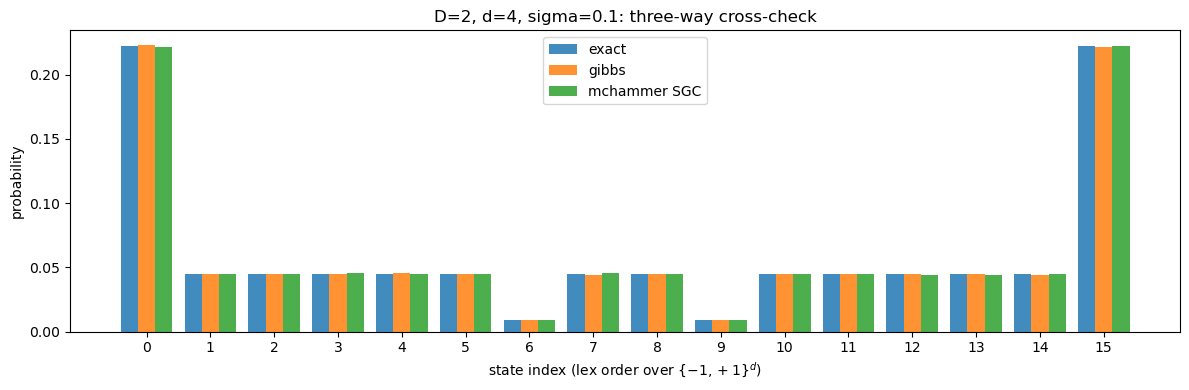

In [8]:
import matplotlib.pyplot as plt

idx = np.arange(2 ** target.d)
width = 0.27
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(idx - width, p_exact.numpy(), width=width, label='exact', alpha=0.85)
ax.bar(idx, p_gibbs.numpy(), width=width, label='gibbs', alpha=0.85)
ax.bar(idx + width, p_sgc.numpy(), width=width, label='mchammer SGC', alpha=0.85)
ax.set_xlabel(r'state index (lex order over $\{-1,+1\}^d$)')
ax.set_ylabel('probability')
ax.set_title(f'D={D}, d={target.d}, sigma={sigma}: three-way cross-check')
ax.set_xticks(idx)
ax.legend()
plt.tight_layout()
plt.show()